n_examples=10  sent=(10, 5196)  received=(10, 5196)
mod=qpsk  dc_offset_A=0.122


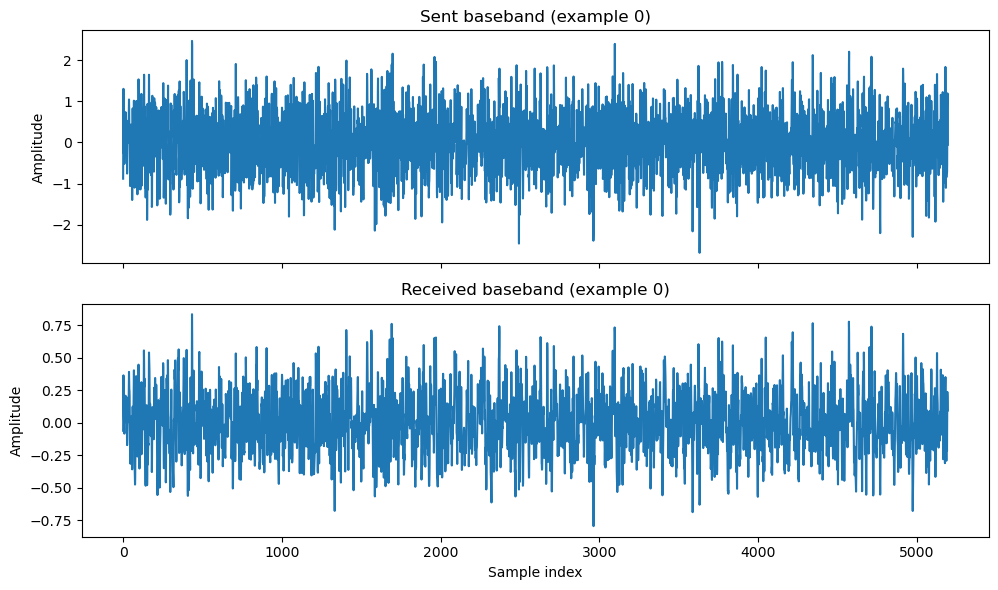

In [1]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

def load_and_plot_first(dataset_path):
    g = zarr.open_group(dataset_path, mode="r")
    sent = np.asarray(g["sent_baseband"])
    received = np.asarray(g["received_baseband"])
    print(f"n_examples={sent.shape[0]}  sent={sent.shape}  received={received.shape}")
    print(f"mod={g.attrs.get('modulation_format')}  dc_offset_A={g.attrs.get('dc_offset_A')}")

    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(sent[0]);     ax[0].set_title("Sent baseband (example 0)");     ax[0].set_ylabel("Amplitude")
    ax[1].plot(received[0]); ax[1].set_title("Received baseband (example 0)"); ax[1].set_ylabel("Amplitude")
    ax[1].set_xlabel("Sample index")
    plt.tight_layout()
    plt.show()
    return sent, received

sent, received = load_and_plot_first("/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.122A_fmin300000_fmax1.299e+07_20260615_1430.zarr")


In [12]:
from modules.models import TCN_channel, LRU_channel
import math

# Toy model for calculating receptive field

tcn_hidden_channels = [6, 8, 12, 16, 22]
lru_hidden_dims = [6, 10, 16, 25, 40]


for tcn_hid, lru_hid in zip(tcn_hidden_channels, lru_hidden_dims):
    print('tcn size', tcn_hid)
    print('lru_size', lru_hid)

    tcn = TCN_channel(nlayers=4, dilation_base=3, kernel_size=8, hidden_channels=tcn_hid, gaussian=True, activation='relu')
    tcn_params = tcn.get_num_params()
    print(tcn_params)
    print(f"Receptive field of TCN: {tcn.receptive_field}")

    lru = LRU_channel(n_layers=2, state_dim=16, hidden_dim=lru_hid, gaussian=True)
    lru_params = lru.get_num_params()
    print(lru_params)

    # Selection criterion
    def sel(params, model):
        print(f"{model} Class {round(math.log2(params))}")

    sel(tcn_params, 'tcn')
    sel(lru_params, 'lru')
    print('\n')

tcn size 6
lru_size 6
962
Receptive field of TCN: 281
1087
tcn Class 10
lru Class 10


tcn size 8
lru_size 10
1666
Receptive field of TCN: 281
1907
tcn Class 11
lru Class 11


tcn size 12
lru_size 16
3650
Receptive field of TCN: 281
3377
tcn Class 12
lru Class 12


tcn size 16
lru_size 25
6402
Receptive field of TCN: 281
6122
tcn Class 13
lru Class 13


tcn size 22
lru_size 40
11970
Receptive field of TCN: 281
12137
tcn Class 14
lru Class 14




In [8]:
tcn_hidden_channels = [5, 7, 9, 12, 17]
lru_hidden_dims = [6, 10, 16, 25, 40]


for tcn_hid, lru_hid in zip(tcn_hidden_channels, lru_hidden_dims):
    print('tcn size', tcn_hid)
    print('lru_size', lru_hid)

    tcn = TCN_channel(nlayers=6, dilation_base=2, kernel_size=8, hidden_channels=tcn_hid, gaussian=True, activation='relu')
    tcn_params = tcn.get_num_params()
    print(tcn_params)
    print(f"Receptive field of TCN: {tcn.receptive_field}")

    lru = LRU_channel(n_layers=2, state_dim=16, hidden_dim=lru_hid, gaussian=True)
    lru_params = lru.get_num_params()
    print(lru_params)

    # Selection criterion
    def sel(params, model):
        print(f"{model} Class {round(math.log2(params))}")

    sel(tcn_params, 'tcn')
    sel(lru_params, 'lru')
    print('\n')

tcn size 5
lru_size 6
1092
Receptive field of TCN: 442
1087
tcn Class 10
lru Class 10


tcn size 7
lru_size 10
2088
Receptive field of TCN: 442
1907
tcn Class 11
lru Class 11


tcn size 9
lru_size 16
3404
Receptive field of TCN: 442
3377
tcn Class 12
lru Class 12


tcn size 12
lru_size 25
5978
Receptive field of TCN: 442
6122
tcn Class 13
lru Class 13


tcn size 17
lru_size 40
11868
Receptive field of TCN: 442
12137
tcn Class 14
lru Class 14




4517
Receptive field of TCN: 46


In [1]:
import zarr
import numpy as np

zarr_path = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr"
n_samples = 3

root = zarr.open_group(zarr_path, mode="r")

print("=== attributes ===")
for k, v in root.attrs.items():
    print(f"  {k}: {v}")

print("\n=== arrays ===")
for name in root.array_keys():
    data = root[name][:]
    print(f"\n[{name}]  shape={data.shape}  dtype={data.dtype}")
    print(f"  min={data.min():.4g}  max={data.max():.4g}  mean={data.mean():.4g}")
    for i in range(min(n_samples, len(data))):
        row = data[i]
        print(f"  [{i}]: {np.array2string(row[:8], precision=4, suppress_small=True)}" +
              (" ..." if len(row) > 8 else ""))


=== attributes ===
  dc_offset_A: 0.052
  f_min_hz: 300000.0
  f_max_hz: 7600000.0
  active_carrier_indices: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75]
  cyclic_prefix_length: 76
  preamble_length: 256
  modulation_format: m7_apsk_constellation

=== arrays ===

[source_bits]  shape=(5000, 146)  dtype=uint8
  min=0  max=1  mean=0.5003
  [0]: [0 0 1 0 0 0 1 0] ...
  [1]: [1 0 1 0 0 1 1 0] ...
  [2]: [1 1 0 0 1 1 0 1] ...

[sent_burst]  shape=(5000, 940)  dtype=float32
  min=-3  max=3  mean=-8.677e-05
  [0]: [-0.     -0.1977  0.1788  0.9435  1.7197  2.1439  2.053   1.5582] ...
  [1]: [-0.     -0.1977  0.1788  0.9435  1.7197  2.1439  2.053   1.5582] ...
  [2]: [-0.     -0.1977  0.1788  0.9435  1.7197  2.1439  2.053   1.5582] ...

[received_burst]  sha

In [10]:
from pathlib import Path
from dataclasses import dataclass, field
import numpy as np
import zarr

ZARR_PATH = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr"

@dataclass
class OFDMSettings:
    # stored in zarr attrs
    dc_offset_A: float; f_min_hz: float; f_max_hz: float
    active_carrier_indices: np.ndarray
    cyclic_prefix_length: int; preamble_length: int; modulation_format: str
    # derived
    subcarrier_spacing_hz: float = None
    num_carriers: int = None
    subcarrier_freqs_hz: np.ndarray = None
    burst_length: int = None
    baseband_fft_length: int = None
    symbol_length_with_cp: int = None
    baseband_sampling_rate_hz: float = None
    upsample_factor: int = None
    num_leading_zero_subcarriers: int = None
    bits_per_symbol: int = None
    num_samples: int = None

def load_ofdm_dataset(zarr_path):
    g = zarr.open_group(str(zarr_path), mode="r")
    a = dict(g.attrs)
    active   = np.asarray(a["active_carrier_indices"], dtype=int)
    f_min    = float(a["f_min_hz"])
    cp       = int(a["cyclic_prefix_length"])
    preamble = int(a["preamble_length"])

    arrays = {n: g[n] for n in ("sent_burst", "received_burst", "source_bits", "decoded_bits")}
    num_samples, burst_length = arrays["sent_burst"].shape
    bits_per_row = arrays["source_bits"].shape[1]

    # subcarrier k -> k*spacing, first active carrier sits at f_min  =>  spacing = f_min / active[0]
    spacing = f_min / int(active[0])
    # burst = preamble + (fft + cp), all baseband
    fft_len = burst_length - preamble - cp
    fs      = fft_len * spacing
    n_carriers    = len(active)
    leading_zeros = int(active[0]) - 1                 # bins between DC and f_min (DC excluded)
    denom   = 2 * (n_carriers + leading_zeros + 1)     # fft_len = upsample * denom
    upsample = fft_len // denom if fft_len % denom == 0 else fft_len / denom

    s = OFDMSettings(
        dc_offset_A=float(a["dc_offset_A"]), f_min_hz=f_min, f_max_hz=float(a["f_max_hz"]),
        active_carrier_indices=active, cyclic_prefix_length=cp, preamble_length=preamble,
        modulation_format=str(a["modulation_format"]),
        subcarrier_spacing_hz=spacing, num_carriers=n_carriers,
        subcarrier_freqs_hz=active * spacing, burst_length=int(burst_length),
        baseband_fft_length=int(fft_len), symbol_length_with_cp=int(fft_len + cp),
        baseband_sampling_rate_hz=fs, upsample_factor=upsample,
        num_leading_zero_subcarriers=leading_zeros,
        bits_per_symbol=int(round(bits_per_row / n_carriers)), num_samples=int(num_samples),
    )
    return s, arrays

settings, arrays = load_ofdm_dataset(ZARR_PATH)
for k, v in vars(settings).items():
    if isinstance(v, np.ndarray):
        v = f"[{len(v)} vals] {v[:3].tolist()}...{v[-3:].tolist()}"
    print(f"{k:<28} = {v}")

# optional: rebuild the exact constellation object the experiment used
# import sys; sys.path.insert(0, "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED")
# from modules.constellation_diagram import get_constellation
# constellation = get_constellation(settings.modulation_format)


dc_offset_A                  = 0.052
f_min_hz                     = 300000.0
f_max_hz                     = 7600000.0
active_carrier_indices       = [73 vals] [3, 4, 5]...[73, 74, 75]
cyclic_prefix_length         = 76
preamble_length              = 256
modulation_format            = m7_apsk_constellation
subcarrier_spacing_hz        = 100000.0
num_carriers                 = 73
subcarrier_freqs_hz          = [73 vals] [300000.0, 400000.0, 500000.0]...[7300000.0, 7400000.0, 7500000.0]
burst_length                 = 940
baseband_fft_length          = 608
symbol_length_with_cp        = 684
baseband_sampling_rate_hz    = 60800000.0
upsample_factor              = 4
num_leading_zero_subcarriers = 2
bits_per_symbol              = 2
num_samples                  = 5000


In [17]:
np.arange(3, 76) * 1.125

array([ 3.375,  4.5  ,  5.625,  6.75 ,  7.875,  9.   , 10.125, 11.25 ,
       12.375, 13.5  , 14.625, 15.75 , 16.875, 18.   , 19.125, 20.25 ,
       21.375, 22.5  , 23.625, 24.75 , 25.875, 27.   , 28.125, 29.25 ,
       30.375, 31.5  , 32.625, 33.75 , 34.875, 36.   , 37.125, 38.25 ,
       39.375, 40.5  , 41.625, 42.75 , 43.875, 45.   , 46.125, 47.25 ,
       48.375, 49.5  , 50.625, 51.75 , 52.875, 54.   , 55.125, 56.25 ,
       57.375, 58.5  , 59.625, 60.75 , 61.875, 63.   , 64.125, 65.25 ,
       66.375, 67.5  , 68.625, 69.75 , 70.875, 72.   , 73.125, 74.25 ,
       75.375, 76.5  , 77.625, 78.75 , 79.875, 81.   , 82.125, 83.25 ,
       84.375])

In [16]:
import torch
x = torch.arange(3, 76)*1.125
x.round().long()

tensor([ 3,  4,  6,  7,  8,  9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22,
        24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 42, 43,
        44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 63,
        64, 65, 66, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83,
        84])

In [3]:
import numpy as np, zarr

g = zarr.open_group("/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr", mode="r")
a = dict(g.attrs)
active = np.asarray(a["active_carrier_indices"], int)
cp, pre = int(a["cyclic_prefix_length"]), int(a["preamble_length"])
sent, recv = g["sent_burst"], g["received_burst"]
N = sent.shape[1] - pre - cp                      # 608

def carrier_syms(burst_rows, delta=0):
    w = burst_rows[:, pre+cp+delta : pre+cp+delta+N]
    return np.fft.fft(w, norm="ortho", axis=1)[:, active]

X = carrier_syms(sent[:])
Y = carrier_syms(recv[:])
H = (Y / X).mean(0)                                # averaged channel per carrier
phase = np.unwrap(np.angle(H))
slope = np.polyfit(active, phase, 1)[0]            # rad per carrier index
delta_samples = slope * N / (2*np.pi)
print(f"channel timing offset  ≈ {delta_samples:+.3f} samples  (slope {slope:+.4f} rad/carrier)")


channel timing offset  ≈ +1.293 samples  (slope +0.0134 rad/carrier)


In [8]:
import numpy as np, zarr

# ---- point these at the two datasets you're comparing ----
COLLECTION = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr"
VAL_MODEL  = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/experiments/train_and_validate/solar_storm_ed_validation_20260702_0127/validation.zarr/tcn_ae_830cebe2_9b00089d"

# ---- OFDM geometry comes from the collection zarr attrs (same experiment) ----
g = zarr.open_group(COLLECTION, mode="r")
a = dict(g.attrs)
active = np.asarray(a["active_carrier_indices"], int)
cp, pre = int(a["cyclic_prefix_length"]), int(a["preamble_length"])
sent_burst, recv_burst = g["sent_burst"][:], g["received_burst"][:]
N = sent_burst.shape[1] - pre - cp                       # 608

def phase_slope(Y, X):
    """Return (delta_samples, slope_rad_per_carrier) of the linear phase ramp of <Y/X>."""
    H = (Y / X).mean(0)
    slope = np.polyfit(active, np.unwrap(np.angle(H)), 1)[0]
    return slope * N / (2*np.pi), slope

def syms_from_bursts(rows, delta=0):
    """FFT the post-CP window (offset by delta) of full [preamble|CP|symbol] rows."""
    w = rows[:, pre+cp+delta : pre+cp+delta+N]
    return np.fft.fft(w, norm="ortho", axis=1)[:, active]

def syms_from_symbols(rows):
    """validation.zarr rows are already the N-length symbol (CP/preamble stripped)."""
    return np.fft.fft(rows, norm="ortho", axis=1)[:, active]

# ===== Test A: timing offset in each environment =====
Xc = syms_from_bursts(sent_burst)
d_chan, s_chan = phase_slope(syms_from_bursts(recv_burst), Xc)

vg = zarr.open_group(VAL_MODEL, mode="r")
Xv, Yv = syms_from_symbols(vg["sent_time"][:]), syms_from_symbols(vg["received_time"][:])
d_val, s_val = phase_slope(Yv, Xv)

print(f"COLLECTION (channel, no eq): delta = {d_chan:+.3f} samp   slope {s_chan:+.4f} rad/carrier")
print(f"VALIDATION residual (post-decoder, {vg.attrs.get('channel_form','?')}): "
      f"delta = {d_val:+.3f} samp   slope {s_val:+.4f} rad/carrier")
print(f"--> environment mismatch: {d_val - d_chan:+.3f} samples\n")

# ===== Test B: window-offset sweep on collection data (AWG loops -> tile to emulate) =====
loop = np.concatenate([recv_burst, recv_burst], axis=1)   # burst is periodic in the AWG table
Href = (syms_from_bursts(recv_burst) / Xc).mean(0)         # 1-tap equalizer fit at delta=0
print("delta  EVM%   (early=CP-protected, late=next-preamble leakage)")
best = (1e9, 0)
for d in range(-30, 31, 2):
    Yk = np.fft.fft(loop[:, pre+cp+d:pre+cp+d+N], norm="ortho", axis=1)[:, active]
    evm = np.sqrt(np.mean(np.abs(Yk/Href - Xc)**2) / np.mean(np.abs(Xc)**2)) * 100
    best = min(best, (evm, d))
    bar = "#" * int(min(evm, 60))
    print(f"{d:+4d}  {evm:6.2f}  {bar}")
print(f"\nEVM-optimal window offset: delta* = {best[1]:+d} samples (EVM {best[0]:.2f}%)")


COLLECTION (channel, no eq): delta = +1.293 samp   slope +0.0134 rad/carrier
VALIDATION residual (post-decoder, nonprob TCN): delta = +0.006 samp   slope +0.0001 rad/carrier
--> environment mismatch: -1.286 samples

delta  EVM%   (early=CP-protected, late=next-preamble leakage)
 -30  152.65  ############################################################
 -28  149.39  ############################################################
 -26  146.61  ############################################################
 -24  150.42  ############################################################
 -22  153.74  ############################################################
 -20  149.44  ############################################################
 -18  145.21  ############################################################
 -16  150.59  ############################################################
 -14  155.99  ############################################################
 -12  149.38  ################################

COLLECTION channel (no eq)       delta= +1.293 samp | de-ramped residual RMS =  6.72 deg
VALIDATION residual (post-E/D)   delta= +0.006 samp | de-ramped residual RMS =  6.01 deg


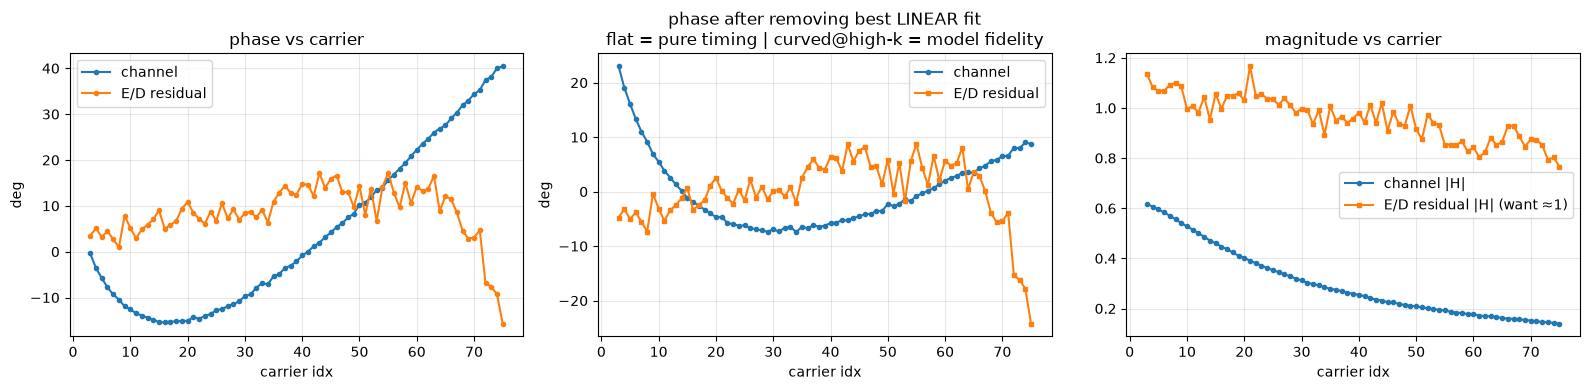

In [9]:
import numpy as np, zarr
import matplotlib.pyplot as plt

COLLECTION = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr"
VAL_MODEL  = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/experiments/train_and_validate/solar_storm_ed_validation_20260702_0127/validation.zarr/tcn_ae_830cebe2_9b00089d"

g = zarr.open_group(COLLECTION, mode="r"); a = dict(g.attrs)
active = np.asarray(a["active_carrier_indices"], int)
cp, pre = int(a["cyclic_prefix_length"]), int(a["preamble_length"])
sent_burst, recv_burst = g["sent_burst"][:], g["received_burst"][:]
N = sent_burst.shape[1] - pre - cp

def car(rows, stripped=False):
    w = rows if stripped else rows[:, pre+cp:pre+cp+N]      # validation rows are already the N-sample symbol
    return np.fft.fft(w, norm="ortho", axis=1)[:, active]

Xc, Yc = car(sent_burst), car(recv_burst)
vg = zarr.open_group(VAL_MODEL, mode="r")
Xv, Yv = car(vg["sent_time"][:], stripped=True), car(vg["received_time"][:], stripped=True)

def analyze(Y, X, label):
    H  = (Y / X).mean(0)
    ph = np.unwrap(np.angle(H))
    slope, intercept = np.polyfit(active, ph, 1)         # best-fit linear = pure-timing component
    resid = ph - (slope*active + intercept)              # what's left is NOT timing
    delta = slope * N / (2*np.pi)
    print(f"{label:32s} delta={delta:+7.3f} samp | de-ramped residual RMS = "
          f"{np.degrees(np.sqrt(np.mean(resid**2))):5.2f} deg")
    return H, ph, resid

Hc, phc, rc = analyze(Yc, Xc, "COLLECTION channel (no eq)")
Hv, phv, rv = analyze(Yv, Xv, "VALIDATION residual (post-E/D)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for k, y, lab in [(active, np.degrees(phc), "channel"), (active, np.degrees(phv), "E/D residual")]:
    ax[0].plot(k, y, "o-", ms=3, label=lab)
ax[0].set(title="phase vs carrier", xlabel="carrier idx", ylabel="deg"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(active, np.degrees(rc), "o-", ms=3, label="channel")
ax[1].plot(active, np.degrees(rv), "s-", ms=3, label="E/D residual")
ax[1].set(title="phase after removing best LINEAR fit\nflat = pure timing | curved@high-k = model fidelity",
          xlabel="carrier idx", ylabel="deg"); ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(active, np.abs(Hc), "o-", ms=3, label="channel |H|")
ax[2].plot(active, np.abs(Hv), "s-", ms=3, label="E/D residual |H| (want ≈1)")
ax[2].set(title="magnitude vs carrier", xlabel="carrier idx"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()


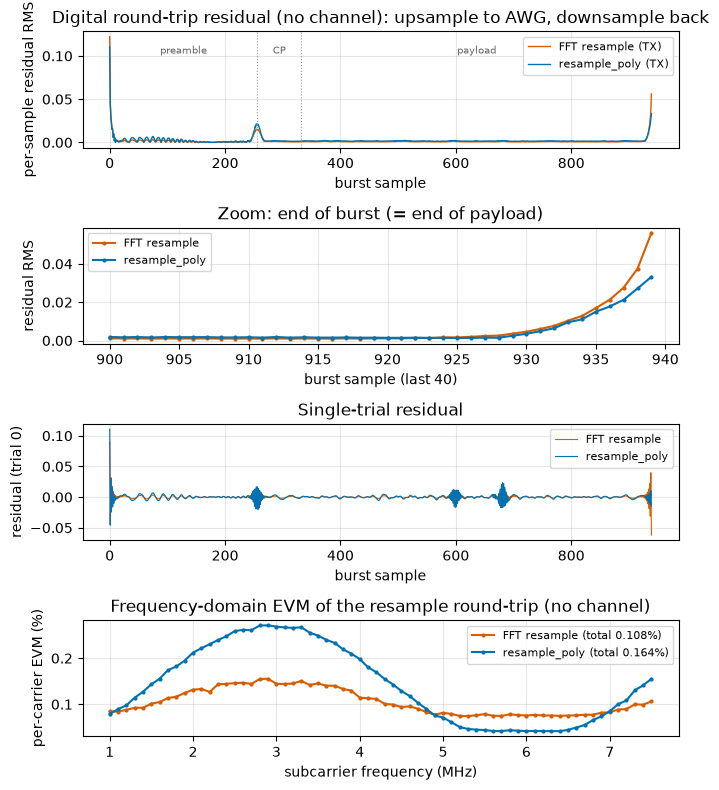

interior median RMS: FFT=0.0009  poly=0.0016
last-sample RMS    : FFT=0.0562  poly=0.0333
last/interior ratio: FFT=60x  poly=21x
frequency-domain EVM: FFT=0.108%  poly=0.164%


In [15]:
from pathlib import Path

import numpy as np
import zarr
from scipy.signal import resample, resample_poly
import matplotlib.pyplot as plt

# locate the repo root (walk up until we find data/sweeps), so the cell works
# regardless of where the notebook lives
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/sweeps").exists())
DATASET_PATH = REPO_ROOT / "data/sweeps/fresh_echo_dc0.05A_fmin1e+06_fmax7.6e+06_20260715_1828.zarr"
DATA_PLOTS = REPO_ROOT / "data/plots"

AWG_LENGTH = 2000
NUM_BURSTS = 200

dataset = zarr.open_group(str(DATASET_PATH), mode="r")
attrs = dict(dataset.attrs)
preamble_length = int(attrs["preamble_length"])
cyclic_prefix_length = int(attrs["cyclic_prefix_length"])
active_carrier_indices = np.array(attrs["active_carrier_indices"])
subcarrier_spacing = attrs["f_min_hz"] / active_carrier_indices.min()
subcarrier_freqs_mhz = active_carrier_indices * subcarrier_spacing / 1e6

bursts = dataset["sent_burst"][:NUM_BURSTS].astype(np.float64)  # baseband [preamble | CP | payload]
burst_length = bursts.shape[1]
payload_start = preamble_length + cyclic_prefix_length


def roundtrip(upsample_fn):
    """Upsample each baseband burst to the AWG length, downsample it back (RX is always
    polyphase), and return the recovered bursts. No channel, no hardware."""
    recovered = []
    for burst in bursts:
        awg_waveform = upsample_fn(burst)
        recovered.append(resample_poly(awg_waveform, burst_length, AWG_LENGTH)[:burst_length])
    return np.array(recovered)


def demodulate(burst_block):
    """OFDM subcarrier symbols on the active carriers, from the payload (CP stripped)."""
    payload = burst_block[:, payload_start:]
    return np.fft.fft(payload, norm="ortho", axis=1)[:, active_carrier_indices]


def per_carrier_evm(recovered):
    sent_symbols = demodulate(bursts)
    recovered_symbols = demodulate(recovered)
    error = np.abs(recovered_symbols - sent_symbols) ** 2
    reference = np.abs(sent_symbols) ** 2
    return np.sqrt(error.mean(0) / reference.mean(0)) * 100, np.sqrt(error.mean() / reference.mean()) * 100


recovered_fft = roundtrip(lambda b: resample(b, AWG_LENGTH))
recovered_poly = roundtrip(lambda b: resample_poly(b, AWG_LENGTH, len(b)))

residual_fft = bursts - recovered_fft
residual_poly = bursts - recovered_poly
rms_fft = np.sqrt((residual_fft ** 2).mean(0))
rms_poly = np.sqrt((residual_poly ** 2).mean(0))

evm_carrier_fft, evm_total_fft = per_carrier_evm(recovered_fft)
evm_carrier_poly, evm_total_poly = per_carrier_evm(recovered_poly)

fig, (full_ax, zoom_ax, trial_ax, evm_ax) = plt.subplots(4, 1, figsize=(7, 8))

full_ax.plot(rms_fft, color="#D55E00", lw=1.0, label="FFT resample (TX)")
full_ax.plot(rms_poly, color="#0072B2", lw=1.0, label="resample_poly (TX)")
full_ax.axvline(preamble_length, color="#999", ls=":", lw=0.8)
full_ax.axvline(payload_start, color="#999", ls=":", lw=0.8)
full_ax.text(preamble_length / 2, full_ax.get_ylim()[1] * 0.8, "preamble", ha="center", fontsize=7, color="#666")
full_ax.text((preamble_length + payload_start) / 2, full_ax.get_ylim()[1] * 0.8, "CP", ha="center", fontsize=7, color="#666")
full_ax.text((payload_start + burst_length) / 2, full_ax.get_ylim()[1] * 0.8, "payload", ha="center", fontsize=7, color="#666")
full_ax.set_ylabel("per-sample residual RMS")
full_ax.set_xlabel("burst sample")
full_ax.set_title("Digital round-trip residual (no channel): upsample to AWG, downsample back")
full_ax.legend(fontsize=8)
full_ax.grid(True, alpha=0.3)

tail = np.arange(burst_length - 40, burst_length)
zoom_ax.plot(tail, rms_fft[-40:], color="#D55E00", marker=".", ms=4, label="FFT resample")
zoom_ax.plot(tail, rms_poly[-40:], color="#0072B2", marker=".", ms=4, label="resample_poly")
zoom_ax.set_ylabel("residual RMS")
zoom_ax.set_xlabel("burst sample (last 40)")
zoom_ax.set_title("Zoom: end of burst (= end of payload)")
zoom_ax.legend(fontsize=8)
zoom_ax.grid(True, alpha=0.3)

trial_ax.plot(residual_fft[0], color="#D55E00", lw=0.8, label="FFT resample")
trial_ax.plot(residual_poly[0], color="#0072B2", lw=0.8, label="resample_poly")
trial_ax.set_ylabel("residual (trial 0)")
trial_ax.set_xlabel("burst sample")
trial_ax.set_title("Single-trial residual")
trial_ax.legend(fontsize=8)
trial_ax.grid(True, alpha=0.3)

evm_ax.plot(subcarrier_freqs_mhz, evm_carrier_fft, color="#D55E00", marker=".", ms=4,
            label=f"FFT resample (total {evm_total_fft:.3f}%)")
evm_ax.plot(subcarrier_freqs_mhz, evm_carrier_poly, color="#0072B2", marker=".", ms=4,
            label=f"resample_poly (total {evm_total_poly:.3f}%)")
evm_ax.set_ylabel("per-carrier EVM (%)")
evm_ax.set_xlabel("subcarrier frequency (MHz)")
evm_ax.set_title("Frequency-domain EVM of the resample round-trip (no channel)")
evm_ax.legend(fontsize=8)
evm_ax.grid(True, alpha=0.3)

fig.tight_layout()

DATA_PLOTS.mkdir(parents=True, exist_ok=True)
fig.savefig(DATA_PLOTS / "gibbs_residual_replication.png", dpi=130, bbox_inches="tight")
plt.show()

interior = slice(payload_start + 10, -10)
print(f"interior median RMS: FFT={np.median(rms_fft[interior]):.4f}  poly={np.median(rms_poly[interior]):.4f}")
print(f"last-sample RMS    : FFT={rms_fft[-1]:.4f}  poly={rms_poly[-1]:.4f}")
print(f"last/interior ratio: FFT={rms_fft[-1] / np.median(rms_fft[interior]):.0f}x  "
      f"poly={rms_poly[-1] / np.median(rms_poly[interior]):.0f}x")
print(f"frequency-domain EVM: FFT={evm_total_fft:.3f}%  poly={evm_total_poly:.3f}%")


guard=  0: last-sample RMS=0.0562  interior=0.0009  ratio=60x
guard=  8: last-sample RMS=0.0117  interior=0.0009  ratio=13x
guard= 32: last-sample RMS=0.0117  interior=0.0009  ratio=13x


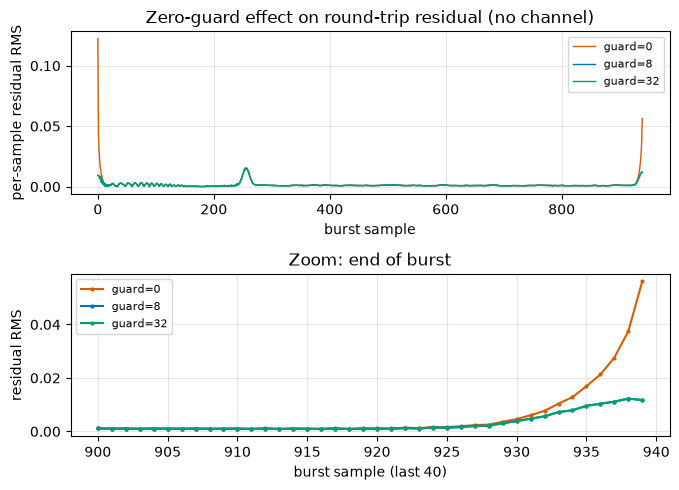

In [12]:
from pathlib import Path

import numpy as np
import zarr
from scipy.signal import resample, resample_poly
import matplotlib.pyplot as plt

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/sweeps").exists())
DATASET_PATH = REPO_ROOT / "data/sweeps/fresh_echo_dc0.05A_fmin1e+06_fmax7.6e+06_20260715_1828.zarr"
DATA_PLOTS = REPO_ROOT / "data/plots"

AWG_LENGTH = 2000
NUM_BURSTS = 200
GUARD_SAMPLES = [0, 8, 32]         # zero-guard widths (baseband samples) to compare
UPSAMPLE = resample                # FFT resample = worst-case Gibbs; use resample_poly for that path

dataset = zarr.open_group(str(DATASET_PATH), mode="r")
attrs = dict(dataset.attrs)
preamble_length = int(attrs["preamble_length"])
cyclic_prefix_length = int(attrs["cyclic_prefix_length"])

bursts = dataset["sent_burst"][:NUM_BURSTS].astype(np.float64)
burst_length = bursts.shape[1]
resample_ratio = AWG_LENGTH / burst_length


def guarded_roundtrip_rms(guard):
    """Pad each burst with `guard` zeros on both ends, run the upsample->downsample
    round-trip, strip the guards, and return the per-sample residual RMS of the burst.
    The resample ratio is held fixed so only the guard width changes."""
    residuals = []
    for burst in bursts:
        padded = np.concatenate([np.zeros(guard), burst, np.zeros(guard)])
        awg_length = round(len(padded) * resample_ratio)
        upsampled = UPSAMPLE(padded, awg_length)
        recovered = resample_poly(upsampled, len(padded), awg_length)[:len(padded)]
        recovered_burst = recovered[guard:guard + burst_length]
        residuals.append(burst - recovered_burst)
    return np.sqrt((np.array(residuals) ** 2).mean(0))


colors = ["#D55E00", "#0072B2", "#009E73"]

fig, (full_ax, zoom_ax) = plt.subplots(2, 1, figsize=(7, 5))

for guard, color in zip(GUARD_SAMPLES, colors):
    rms = guarded_roundtrip_rms(guard)

    full_ax.plot(rms, color=color, lw=1.0, label=f"guard={guard}")
    zoom_ax.plot(np.arange(burst_length - 40, burst_length), rms[-40:],
                 color=color, marker=".", ms=4, label=f"guard={guard}")

    interior = np.median(rms[preamble_length + cyclic_prefix_length + 10:-10])
    print(f"guard={guard:3d}: last-sample RMS={rms[-1]:.4f}  interior={interior:.4f}  "
          f"ratio={rms[-1] / interior:.0f}x")

full_ax.set_ylabel("per-sample residual RMS")
full_ax.set_xlabel("burst sample")
full_ax.set_title("Zero-guard effect on round-trip residual (no channel)")
full_ax.legend(fontsize=8)
full_ax.grid(True, alpha=0.3)

zoom_ax.set_ylabel("residual RMS")
zoom_ax.set_xlabel("burst sample (last 40)")
zoom_ax.set_title("Zoom: end of burst")
zoom_ax.legend(fontsize=8)
zoom_ax.grid(True, alpha=0.3)

fig.tight_layout()

DATA_PLOTS.mkdir(parents=True, exist_ok=True)
fig.savefig(DATA_PLOTS / "zero_guard_residual.png", dpi=130, bbox_inches="tight")
plt.show()


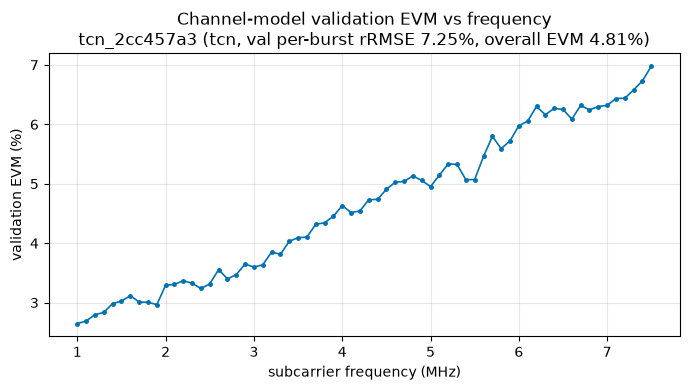

top channel model: tcn_2cc457a3 (tcn)
per-carrier EVM: min 2.65%  max 6.98%  overall 4.81%
top carrier (7.5 MHz): 6.98%


In [18]:
import sys
import json
from pathlib import Path

import numpy as np
import torch
import yaml
import zarr
import matplotlib.pyplot as plt

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/sweeps").exists())
sys.path.insert(0, str(REPO_ROOT))

from modules.grid_search.adapters import MODEL_REGISTRY
from modules.utils import load_ofdm_dataset

CHANNEL_DIR = REPO_ROOT / "data/experiments/train_and_validate/fresh_echo_channel_models_20260716_1726"
DATASET_PATH = REPO_ROOT / "data/sweeps/fresh_echo_dc0.05A_fmin1e+06_fmax7.6e+06_20260715_1828.zarr"
DATA_PLOTS = REPO_ROOT / "data/plots"
SEED = 0                 # matches RUNTIME.SEED used by the channel grid search
VAL_FRACTION = 0.1       # matches CHANNEL_GRID_SEARCH.VAL_FRACTION
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# best TCN channel model = lowest held-out per-burst rRMSE among TCN runs
channel_runs = [json.loads(line) for line in (CHANNEL_DIR / "runs.jsonl").read_text().splitlines() if line.strip()]
top_run = min((r for r in channel_runs if r["model"] == "tcn"),
              key=lambda r: r.get("val_per_burst_rrmse_pct", float("inf")))

params = yaml.safe_load((CHANNEL_DIR / "runs" / top_run["run_id"] / "config.yaml").read_text())["params"]
adapter = MODEL_REGISTRY[top_run["model"]].load(params, CHANNEL_DIR / "runs" / top_run["run_id"] / "model.pt", DEVICE)

# reproduce the grid search's held-out validation split
sent, received, ofdm_config = load_ofdm_dataset(str(DATASET_PATH), DEVICE)
preamble_length = sent.shape[1] - ofdm_config.baseband_fft_length - ofdm_config.cyclic_prefix_length
sent, received = sent[:, preamble_length:], received[:, preamble_length:]   # OFDM symbol (CP + payload)

num_bursts = sent.shape[0]
num_val = round(num_bursts * VAL_FRACTION)
permutation = torch.randperm(num_bursts, generator=torch.Generator().manual_seed(SEED))
val_indices = permutation[:num_val]
sent_val, received_val = sent[val_indices], received[val_indices]

predicted = adapter.predict(sent_val)
predicted_val = predicted[1] if isinstance(predicted, tuple) else predicted   # mean prediction

# per-carrier EVM of the model's prediction vs the real received symbol
cyclic_prefix_length = ofdm_config.cyclic_prefix_length
attrs = dict(zarr.open_group(str(DATASET_PATH), mode="r").attrs)
active_carrier_indices = np.array(attrs["active_carrier_indices"])
subcarrier_spacing = attrs["f_min_hz"] / active_carrier_indices.min()
subcarrier_freqs_mhz = active_carrier_indices * subcarrier_spacing / 1e6


def carrier_symbols(symbol_block):
    payload = symbol_block[:, cyclic_prefix_length:].detach().cpu().numpy()
    return np.fft.fft(payload, norm="ortho", axis=1)[:, active_carrier_indices]


real_symbols = carrier_symbols(received_val)
predicted_symbols = carrier_symbols(predicted_val)
per_carrier_evm = np.sqrt((np.abs(predicted_symbols - real_symbols) ** 2).mean(0)
                          / (np.abs(real_symbols) ** 2).mean(0)) * 100
overall_evm = np.sqrt((per_carrier_evm ** 2).mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(subcarrier_freqs_mhz, per_carrier_evm, color="#0072B2", marker=".", ms=5, lw=1.2)
ax.set_xlabel("subcarrier frequency (MHz)")
ax.set_ylabel("validation EVM (%)")
ax.set_title(f"Channel-model validation EVM vs frequency\n"
             f"{top_run['run_id']} ({top_run['model']}, val per-burst rRMSE "
             f"{top_run['val_per_burst_rrmse_pct']:.2f}%, overall EVM {overall_evm:.2f}%)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

DATA_PLOTS.mkdir(parents=True, exist_ok=True)
fig.savefig(DATA_PLOTS / "channel_model_val_evm_vs_frequency.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"top channel model: {top_run['run_id']} ({top_run['model']})")
print(f"per-carrier EVM: min {per_carrier_evm.min():.2f}%  max {per_carrier_evm.max():.2f}%  "
      f"overall {overall_evm:.2f}%")
print(f"top carrier ({subcarrier_freqs_mhz[-1]:.1f} MHz): {per_carrier_evm[-1]:.2f}%")
